In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from limTOD import (
    TODSim,
    example_scan,
    example_beam_map,
    example_symm_beam_map,
    pointing_beam_in_eq_sys,
    GDSM_sky_model,
)
# Note: To use TIBEC, you need to install it separately by:
# pip install git+https://github.com/zzhang0123/TIBEC.git

from tibec import compute_stokes_beams, load_efield_txt, E_field

In [4]:
def beam_func(freq_ind=0, nside=64):
    """Return Full Stokes beam for REACH E-field data.

    Parameters
    ----------
    freq_ind : int
        Frequency channel index (0–25 for the 26-channel REACH file).
    nside : int
        HEALPix Nside parameter.

    Returns
    -------
    beam : ndarray, shape (4, npix)
        Full Stokes beam (I, Q, U, V).
    """
    stokes, _ = compute_stokes_beams(
        "/Users/zzhang/Workspace/TIBEC/data/REACH_Efield.txt",
        n_phi=73,
        n_theta=37,
        n_freq=26,
        freq_ind=freq_ind,
        nside=nside,
    )
    return stokes.T  # (npix, 4) -> (4, npix)

In [5]:
import pickle
with open("/Users/zzhang/Workspace/TIBEC/data/REACH_beam_func.pkl", "rb") as f:
    beam_func = pickle.load(f)
beam = beam_func(freq_ind=0, nside=32)

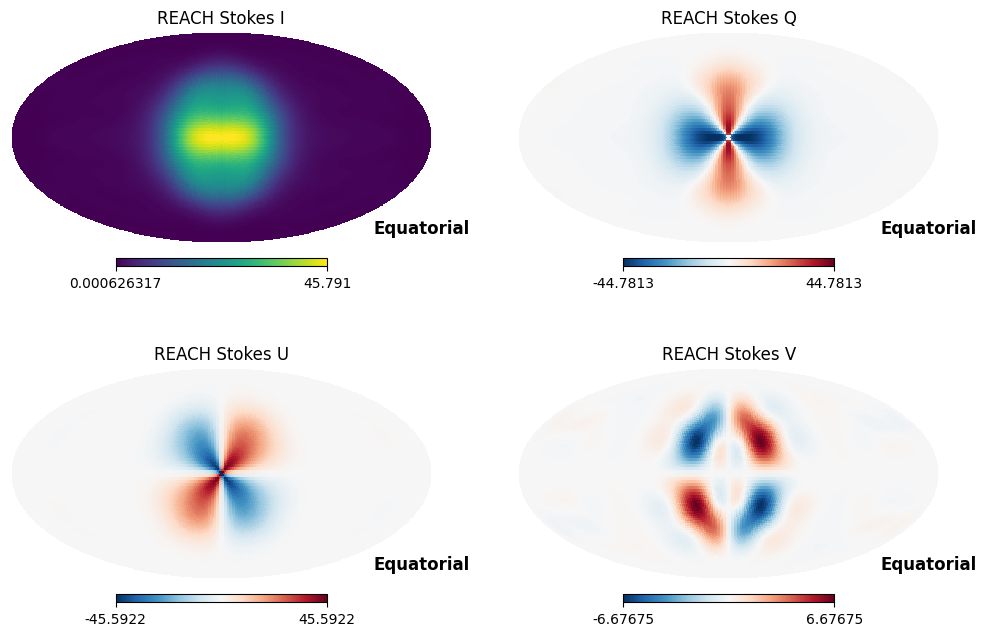

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
labels = ["Stokes I", "Stokes Q", "Stokes U", "Stokes V"]

for p in range(4):
    plt.subplot(2, 2, p + 1)
    kwargs = dict(title=f"REACH {labels[p]}", rot=(0, 90, 0),
                  hold=True, coord="C", flip="geo")
    if p > 0:  # Q, U, V
        val = np.max(np.abs(beam[p, :]))
        kwargs.update(min=-val, max=val, cmap="RdBu_r")
    hp.mollview(beam[p, :], **kwargs)

plt.show()

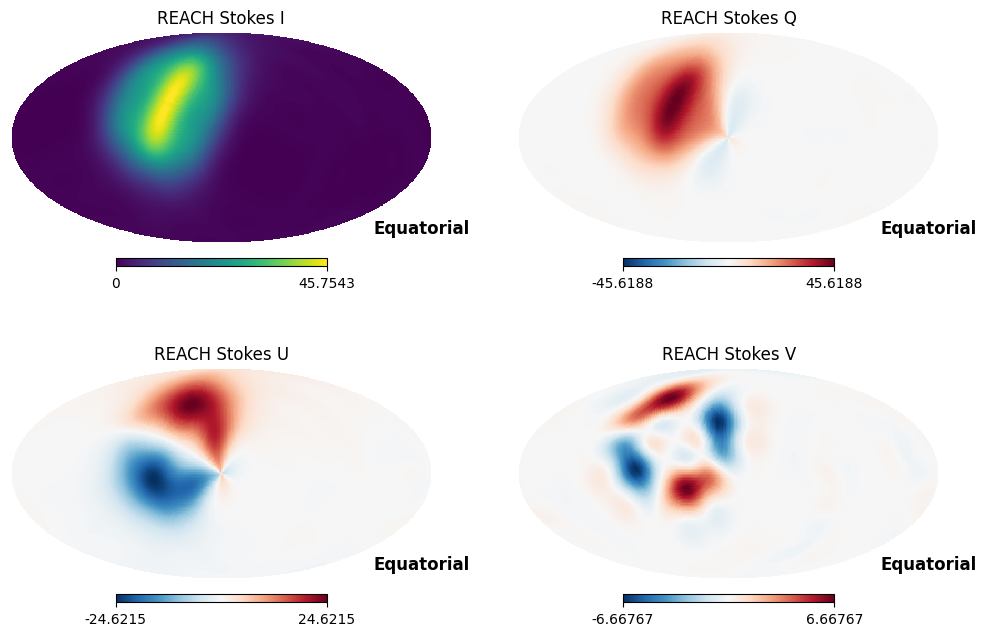

In [21]:
# Pointed Beam Specifications
LST_deg = 60  # degrees
lat_deg = 53  # degrees
azimuth_deg = 0  # degrees
elevation_deg = 0  # degrees
selfrot_deg = 0

# hp.map2alm handles 1 or 3 maps; for 4-component (I,Q,U,V), transform V separately
beam_alm_IQU = hp.map2alm(beam[:3])
beam_alm_V = hp.map2alm(beam[3])
beam_alm = np.array([beam_alm_IQU[0], beam_alm_IQU[1], beam_alm_IQU[2], beam_alm_V])

pointed_beam = pointing_beam_in_eq_sys(
    beam_alm, 
    LST_deg, 
    lat_deg, 
    azimuth_deg, 
    elevation_deg, 
    selfrot_deg,
    64, 
    normalize=False, 
    horizontal_mask=None,
)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
labels = ["Stokes I", "Stokes Q", "Stokes U", "Stokes V"]

for p in range(4):
    plt.subplot(2, 2, p + 1)
    kwargs = dict(title=f"REACH {labels[p]}", rot=(0, 90, 0),
                  hold=True, coord="C", flip="geo")
    if p > 0:  # Q, U, V
        val = np.max(np.abs(pointed_beam[p, :]))
        kwargs.update(min=-val, max=val, cmap="RdBu_r")
    hp.mollview(pointed_beam[p, :], **kwargs)

plt.show()

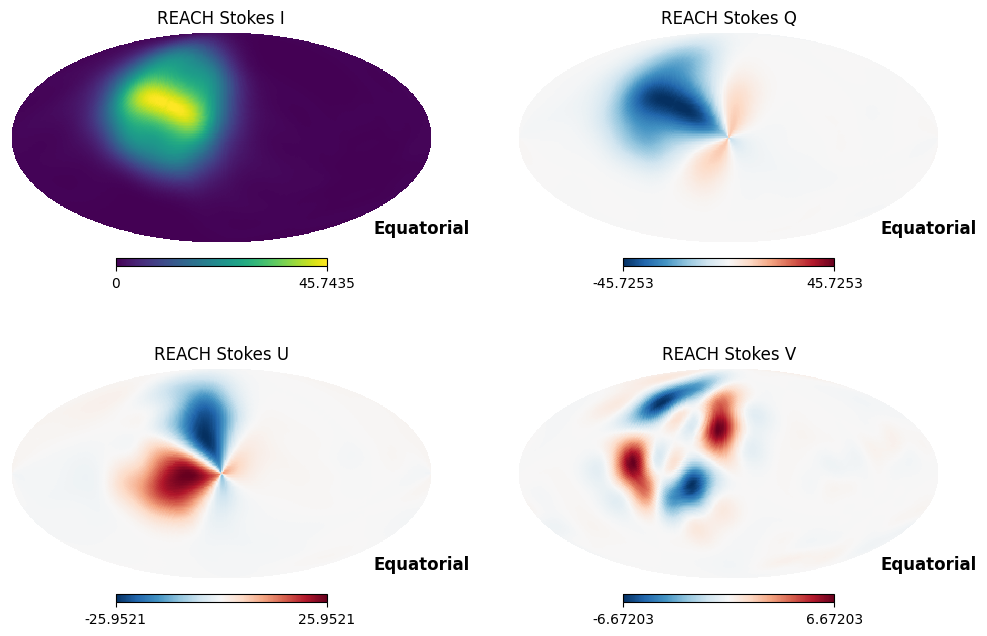

In [22]:
# Pointed Beam Specifications
LST_deg = 60  # degrees
lat_deg = 53  # degrees
azimuth_deg = 0  # degrees
elevation_deg = 0  # degrees
selfrot_deg = 90

# hp.map2alm handles 1 or 3 maps; for 4-component (I,Q,U,V), transform V separately
beam_alm_IQU = hp.map2alm(beam[:3])
beam_alm_V = hp.map2alm(beam[3])
beam_alm = np.array([beam_alm_IQU[0], beam_alm_IQU[1], beam_alm_IQU[2], beam_alm_V])

pointed_beam = pointing_beam_in_eq_sys(
    beam_alm, 
    LST_deg, 
    lat_deg, 
    azimuth_deg, 
    elevation_deg, 
    selfrot_deg,
    64, 
    normalize=False, 
    horizontal_mask=None,
)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
labels = ["Stokes I", "Stokes Q", "Stokes U", "Stokes V"]

for p in range(4):
    plt.subplot(2, 2, p + 1)
    kwargs = dict(title=f"REACH {labels[p]}", rot=(0, 90, 0),
                  hold=True, coord="C", flip="geo")
    if p > 0:  # Q, U, V
        val = np.max(np.abs(pointed_beam[p, :]))
        kwargs.update(min=-val, max=val, cmap="RdBu_r")
    hp.mollview(pointed_beam[p, :], **kwargs)
    
plt.show()

In [14]:
# Initialize the TODsimulator with MeerKAT coordinates
TODsimulator = TODSim(
    ant_latitude_deg=53.2368,  # JBO latitude North is positive
    ant_longitude_deg=-2.3085,  # JBO longitude East is positive
    ant_height_m=77,          # JBO altitude
    beam_func=example_beam_map, # Return HEALPix beam array of shape (hp.nside2npix(nside))
    sky_func=GDSM_sky_model,     # Return HEALPix sky map of shape (hp.nside2npix(nside))
    sky_nside=64,                   # HEALPix resolution
    beam_nside=64
)

In [ ]:
#### Full TOD Generation Example 

# TODsimulator.generate_TOD(
#     freq_list,
#     time_list,
#     azimuth_deg_list,
#     selfrot_deg_list=None,
#     elevation_deg=41.5,
#     start_time_utc="2019-04-23 20:41:56.397",
#     Tsys_others_TOD=None,
#     background_gain_TOD=None,
#     gain_noise_TOD=None,
#     gain_noise_params=[1.335e-5, 1.099e-3, 2],
#     white_noise_var=None,
#     return_LSTs=False,
#     nside_hires=None,
#     normalize_beam=False,
#     horizontal_mask=None,
#     truncate_frac_thres=1e-10
# )

In [ ]:
#### Only to Generate the Sky Component of the TOD

# TODsimulator.simulate_TOD_sky(....)